# Aggregated Seed Statistics Visualization

This notebook loads `aggregated_stats.json`-style output from `scripts/aggregate_seed_statistics.py` and plots seed-level mean preference with 95% confidence intervals.

Change only `INPUT_JSON_PATH` to reuse it for another model/preference. The model and preference are inferred from paths like `plots/{model}/{preference}/aggregated_seed_stats_test.json` or from metadata paths like `workspace/multihop/{model}/{preference}`.

## 1. Imports and Styling

In [238]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# PROJECT_ROOT = Path('/home/abasso_aims_ac_za/divergence-tokens')
PROJECT_ROOT = Path('/home/elisha_aims_ac_za/divergence-tokens')
NOTEBOOK_DIR = PROJECT_ROOT / 'notebooks' / 'eval-pref-with-stats'

FONT_SCALE = 2
FONT_SIZES = {
    'axis_label': 12,
    'axis_label_medium': 14,
    'axis_label_large': 18,
    'annotation': 8,
    'annotation_large': 12,
    'helper_axis_label': 9,
    'helper_tick': 8,
    'legend': 11,
    'legend_small': 9,
    'legend_large': 16,
    'legend_title': 13,
    'tick': 11,
    'tick_large': 18,
    'tick_x_large': 18,
    'value_label': 14,
}

sns.set_theme(style='whitegrid', context='paper', font_scale=FONT_SCALE)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
})

MODE_COLORS = {
    'FT div-tokens': '#ff9500',
    'FT w/o div-tokens': '#377eb8',
    'FT': '#4daf4a',
    'unknown': '#999999',
}
MODE_ORDER = ['FT div-tokens', 'FT', 'FT w/o div-tokens', 'unknown']

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)

print('Imports and styling configured.')

Imports and styling configured.


## 2. Input Configuration

In [239]:
# Change this path to reuse the notebook for another model/preference.
MODEL_NAME = 'qwen'
PREFERENCE_TYPE = 'panda'
INPUT_JSON_PATH = PROJECT_ROOT / 'plots' / MODEL_NAME / PREFERENCE_TYPE / 'aggregated_seed_stats_test.json'

if not INPUT_JSON_PATH.exists():
    raise FileNotFoundError(f'Input file not found: {INPUT_JSON_PATH}')

with INPUT_JSON_PATH.open('r') as handle:
    stats_data = json.load(handle)


def infer_model_preference(input_path: Path, payload: dict) -> tuple[str, str]:
    parts = list(input_path.parts)
    for idx, part in enumerate(parts[:-2]):
        if part == 'plots' and idx + 2 < len(parts):
            return parts[idx + 1], parts[idx + 2]

    parent = payload.get('metadata', {}).get('parent')
    if parent:
        parent_parts = Path(parent).parts
        for idx, part in enumerate(parent_parts[:-2]):
            if part == 'multihop' and idx + 2 < len(parent_parts):
                return parent_parts[idx + 1], parent_parts[idx + 2]

    return 'model', 'preference'


MODEL_NAME, PREFERENCE_TYPE = infer_model_preference(INPUT_JSON_PATH, stats_data)
OUTPUT_DIR = NOTEBOOK_DIR / 'plots' / MODEL_NAME / PREFERENCE_TYPE
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Input: {INPUT_JSON_PATH}')
print(f'Model: {MODEL_NAME}')
print(f'Preference: {PREFERENCE_TYPE}')
print(f'Output directory: {OUTPUT_DIR}')
print()
print('Metadata:')
for key, value in stats_data.get('metadata', {}).items():
    print(f'  {key}: {value}')
print(f"Groups: {len(stats_data.get('groups', {}))}")

Input: /home/elisha_aims_ac_za/divergence-tokens/plots/qwen/panda/aggregated_seed_stats_test.json
Model: qwen
Preference: panda
Output directory: /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/panda

Metadata:
  parent: workspace/multihop/qwen/panda
  metric: mean
  confidence: 0.95
  checkpoint_policy: latest
  n_point_estimates: 61
Groups: 30


## 3. Parse Aggregated Statistics

The plotted error bar is the seed-level 95% confidence interval margin:

`error_pct = margin_error * 100`

This comes from the aggregation script's t-interval over seed means, not from question-level uncertainty.

In [240]:
def parse_hop(value: object) -> int | None:
    text = str(value)
    match = re.search(r'hop(\d+)', text)
    return int(match.group(1)) if match else None


def classify_mode(train_mode: str) -> str:
    text = str(train_mode).lower().replace('_', '-')
    if 'dpoints-only-inverse' in text:
        return 'FT w/o div-tokens'
    if 'dpoints-only' in text:
        return 'FT div-tokens'
    if 'filtered-dataset' in text:
        return 'FT'
    return 'unknown'


def mode_sort_key(label: str) -> tuple[int, str]:
    try:
        return (MODE_ORDER.index(label), label)
    except ValueError:
        return (len(MODE_ORDER), label)


rows = []
for group_key, group_stats in stats_data.get('groups', {}).items():
    hop = parse_hop(group_stats.get('hop') or group_key)
    train_mode = group_stats.get('train_mode', 'unknown')
    mean = group_stats.get('mean', np.nan)
    margin_error = group_stats.get('margin_error', np.nan)
    lower_bound = group_stats.get('lower_bound', np.nan)
    upper_bound = group_stats.get('upper_bound', np.nan)
    rows.append({
        'group_key': group_key,
        'hop': hop,
        'train_mode': train_mode,
        'mode_label': classify_mode(train_mode),
        'eval_name': group_stats.get('eval_name', ''),
        'checkpoint': group_stats.get('checkpoint', ''),
        'n_seeds': group_stats.get('n_seeds', 0),
        'mean': mean,
        'std': group_stats.get('std', np.nan),
        'se': group_stats.get('se', np.nan),
        't_critical': group_stats.get('t_critical', np.nan),
        'margin_error': margin_error,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
    })

df = pd.DataFrame(rows)
for col in ['mean', 'std', 'se', 't_critical', 'margin_error', 'lower_bound', 'upper_bound']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['mean_pct'] = df['mean'] * 100
# Use margin_error directly for plotting. Bounds are kept for diagnostics.
df['error_pct'] = df['margin_error'] * 100
df['lower_pct'] = df['lower_bound'] * 100
df['upper_pct'] = df['upper_bound'] * 100

plot_df = df.dropna(subset=['hop', 'mean_pct']).copy()
plot_df['hop'] = plot_df['hop'].astype(int)
plot_df = plot_df.sort_values(['hop', 'mode_label'])

print(f'Processed groups: {len(df)}')
print(f'Usable plot rows: {len(plot_df)}')
print(f"Hops: {sorted(plot_df['hop'].unique().tolist())}")
print(f"Modes: {sorted(plot_df['mode_label'].unique().tolist(), key=mode_sort_key)}")
print(f"Eval names: {sorted(plot_df['eval_name'].dropna().unique().tolist())}")

if (plot_df['mode_label'] == 'unknown').any():
    print()
    print('Warning: some train modes were not recognized:')
    display(plot_df.loc[plot_df['mode_label'] == 'unknown', ['train_mode', 'group_key']].drop_duplicates())

plot_df[['hop', 'mode_label', 'mean_pct', 'error_pct', 'lower_pct', 'upper_pct', 'n_seeds', 't_critical']].head(12)

Processed groups: 30
Usable plot rows: 30
Hops: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Modes: ['FT div-tokens', 'FT', 'FT w/o div-tokens']
Eval names: ['eval-panda']


,hop,mode_label,mean_pct,error_pct,lower_pct,upper_pct,n_seeds,t_critical
2,0,FT,79.946667,14.741936,65.204731,94.688603,3,4.302653
1,0,FT div-tokens,70.200000,29.134848,41.065152,99.334848,3,4.302653
0,0,FT w/o div-tokens,48.726667,9.241404,39.485263,57.968071,3,4.302653
5,1,FT,28.030000,11.431461,16.598539,39.461461,3,4.302653
4,1,FT div-tokens,47.720000,13.611375,34.108625,61.331375,3,4.302653
3,1,FT w/o div-tokens,26.326667,10.815056,15.511611,37.141723,3,4.302653
8,2,FT,27.880000,9.351319,18.528681,37.231319,3,4.302653
7,2,FT div-tokens,42.276667,7.042709,35.233957,49.319376,3,4.302653
6,2,FT w/o div-tokens,28.186667,2.435004,25.751663,30.621671,3,4.302653
11,3,FT,26.643333,3.716700,22.926634,30.360033,3,4.302653


## 4. Error-Bar Diagnostics

In [241]:
diagnostics = plot_df.copy()
diagnostics['ci_crosses_zero'] = diagnostics['lower_pct'] < 0
diagnostics['ci_above_100'] = diagnostics['upper_pct'] > 100
diagnostics['relative_error'] = diagnostics['error_pct'] / diagnostics['mean_pct'].replace(0, np.nan)

print('Largest 95% CI margins. Large values are expected when n_seeds is small and seed means vary.')
display(
    diagnostics.sort_values('error_pct', ascending=False)[
        ['hop', 'mode_label', 'mean_pct', 'error_pct', 'lower_pct', 'upper_pct', 'n_seeds', 't_critical', 'std', 'se']
    ].head(20)
)

print()
print('Seed counts:')
display(diagnostics.groupby('n_seeds').size().rename('groups').reset_index())

Largest 95% CI margins. Large values are expected when n_seeds is small and seed means vary.


,hop,mode_label,mean_pct,error_pct,lower_pct,upper_pct,n_seeds,t_critical,std,se
1,0,FT div-tokens,70.200000,29.134848,41.065152,99.334848,3,4.302653,0.117284,0.067714
2,0,FT,79.946667,14.741936,65.204731,94.688603,3,4.302653,0.059344,0.034262
4,1,FT div-tokens,47.720000,13.611375,34.108625,61.331375,3,4.302653,0.054793,0.031635
5,1,FT,28.030000,11.431461,16.598539,39.461461,3,4.302653,0.046018,0.026568
17,5,FT,24.390000,11.054398,13.335602,35.444398,2,12.706205,0.012304,0.008700
3,1,FT w/o div-tokens,26.326667,10.815056,15.511611,37.141723,3,4.302653,0.043536,0.025136
8,2,FT,27.880000,9.351319,18.528681,37.231319,3,4.302653,0.037644,0.021734
0,0,FT w/o div-tokens,48.726667,9.241404,39.485263,57.968071,3,4.302653,0.037202,0.021478
13,4,FT div-tokens,37.030000,8.443766,28.586234,45.473766,3,4.302653,0.033991,0.019625
10,3,FT div-tokens,38.426667,7.811036,30.615630,46.237703,3,4.302653,0.031444,0.018154



Seed counts:


,n_seeds,groups
0,1,14
1,2,1
2,3,15


## 5. Plot Helpers

In [242]:
def save_figure(fig, stem: str):
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    png_path = OUTPUT_DIR / f'{stem}.png'
    pdf_path = OUTPUT_DIR / f'{stem}.pdf'
    fig.savefig(png_path, dpi=300, bbox_inches='tight')
    fig.savefig(pdf_path, dpi=300, bbox_inches='tight')
    print(f'Saved {png_path}')
    print(f'Saved {pdf_path}')
    return png_path, pdf_path


def set_common_axis_style(ax, xlabel: str, ylabel: str):
    ax.set_xlabel(xlabel, fontsize=FONT_SIZES['axis_label_large'])
    ax.set_ylabel(ylabel, fontsize=FONT_SIZES['axis_label_large'])
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    ax.grid(True, axis='y', alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=FONT_SIZES['tick'])


def y_axis_upper(work: pd.DataFrame) -> float:
    upper = (work['mean_pct'] + work['error_pct'].fillna(0)).max()
    if pd.isna(upper):
        return 10.0
    return max(10.0, min(105.0, upper * 1.12))


def plot_rows_for_mode(work: pd.DataFrame, mode: str) -> pd.DataFrame:
    work = work.copy()
    work['mode_label'] = pd.Categorical(work['mode_label'], categories=[mode], ordered=True)
    return work[work['mode_label'] == mode].sort_values('hop')

print('Plot helpers ready.')

Plot helpers ready.


## 6. Plots

In [243]:
def plot_mean_with_ci_by_hop(work: pd.DataFrame) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(18, 9))
    if work.empty:
        ax.text(0.5, 0.5, 'No aggregated stats found', ha='center', va='center')
        ax.axis('off')
        return fig

    for mode in sorted(work['mode_label'].unique(), key=mode_sort_key):
        mode_data = plot_rows_for_mode(work, mode)
        color = MODE_COLORS.get(mode, '#999999')
        ax.errorbar(
            mode_data['hop'],
            mode_data['mean_pct'],
            yerr=mode_data['error_pct'].fillna(0),
            marker='o',
            label=mode,
            capsize=6,
            capthick=2,
            linewidth=1.5,
            color=color,
        )

    set_common_axis_style(ax, 'Hop', f'Rate of picking {PREFERENCE_TYPE}(%)')
    ax.set_xticks(sorted(work['hop'].unique()))
    ax.set_ylim(bottom=0, top=y_axis_upper(work))
    ax.legend(title='Mode', ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.12), fontsize=FONT_SIZES['legend_large'])
    fig.tight_layout()
    return fig


def plot_bar_by_hop_mode(work: pd.DataFrame) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(19, 9))
    if work.empty:
        ax.text(0.5, 0.5, 'No aggregated stats found', ha='center', va='center')
        ax.axis('off')
        return fig

    hop_order = sorted(work['hop'].unique())
    modes = sorted(work['mode_label'].unique(), key=mode_sort_key)
    x = np.arange(len(hop_order))
    bar_width = 0.35 / len(modes) if len(modes) > 1 else 0.35

    for idx, mode in enumerate(modes):
        mode_data = plot_rows_for_mode(work, mode)
        hop_indices = [hop_order.index(hop) for hop in mode_data['hop']]
        color = MODE_COLORS.get(mode, '#999999')
        ax.bar(
            np.array(hop_indices) + idx * bar_width,
            mode_data['mean_pct'].values,
            bar_width,
            yerr=mode_data['error_pct'].fillna(0).values,
            label=mode,
            color=color,
            capsize=3,
            error_kw={'linewidth': 1.5},
            edgecolor='black',
            linewidth=1.2,
            alpha=0.85,
        )

    set_common_axis_style(ax, 'Hop', f'Rate of picking {PREFERENCE_TYPE}(%)')
    ax.set_xticks(x + bar_width * (len(modes) - 1) / 2)
    ax.set_xticklabels([f'hop{h}' for h in hop_order], fontsize=FONT_SIZES['tick'])
    ax.set_ylim(bottom=0, top=y_axis_upper(work))
    ax.legend(title='Mode', ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.12), fontsize=FONT_SIZES['legend'])
    fig.tight_layout()
    return fig


def plot_summary_heatmap(work: pd.DataFrame) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(10, 6))
    if work.empty:
        ax.text(0.5, 0.5, 'No aggregated stats found', ha='center', va='center')
        ax.axis('off')
        return fig

    work = work.copy()

    # work['mode_label'] = pd.Categorical(work['mode_label'], categories=['FT div-tokens', 'FT', 'FT w/o div-tokens'], ordered=True)
    pivot = work.pivot_table(values='mean_pct', index='mode_label', columns='hop', aggfunc='mean')
    pivot = pivot.reindex([mode for mode in MODE_ORDER if mode in pivot.index])
    pivot = pivot[sorted(pivot.columns)]
    sns.heatmap(
        pivot,
        annot=True,
        fmt='.2f',
        cmap='RdYlGn_r',
        ax=ax,
        cbar_kws={'label': f'Rate of picking {PREFERENCE_TYPE}(%)'},
        vmin=0,
        vmax=100,
        linewidths=2,
        linecolor='white',
        annot_kws={'fontsize': FONT_SIZES['annotation']}
    )
    
    
    ax.set_xlabel('Hop', fontsize=FONT_SIZES['axis_label_large'])
    ax.set_ylabel('Mode', fontsize=FONT_SIZES['axis_label_large'])
    ax.tick_params(labelsize=FONT_SIZES['tick'])
    fig.tight_layout()
    return fig

print('Plot functions ready.')

Plot functions ready.


## 7. Save Figures

Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/panda/qwen_panda_mean_ci_by_hop.png
Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/panda/qwen_panda_mean_ci_by_hop.pdf


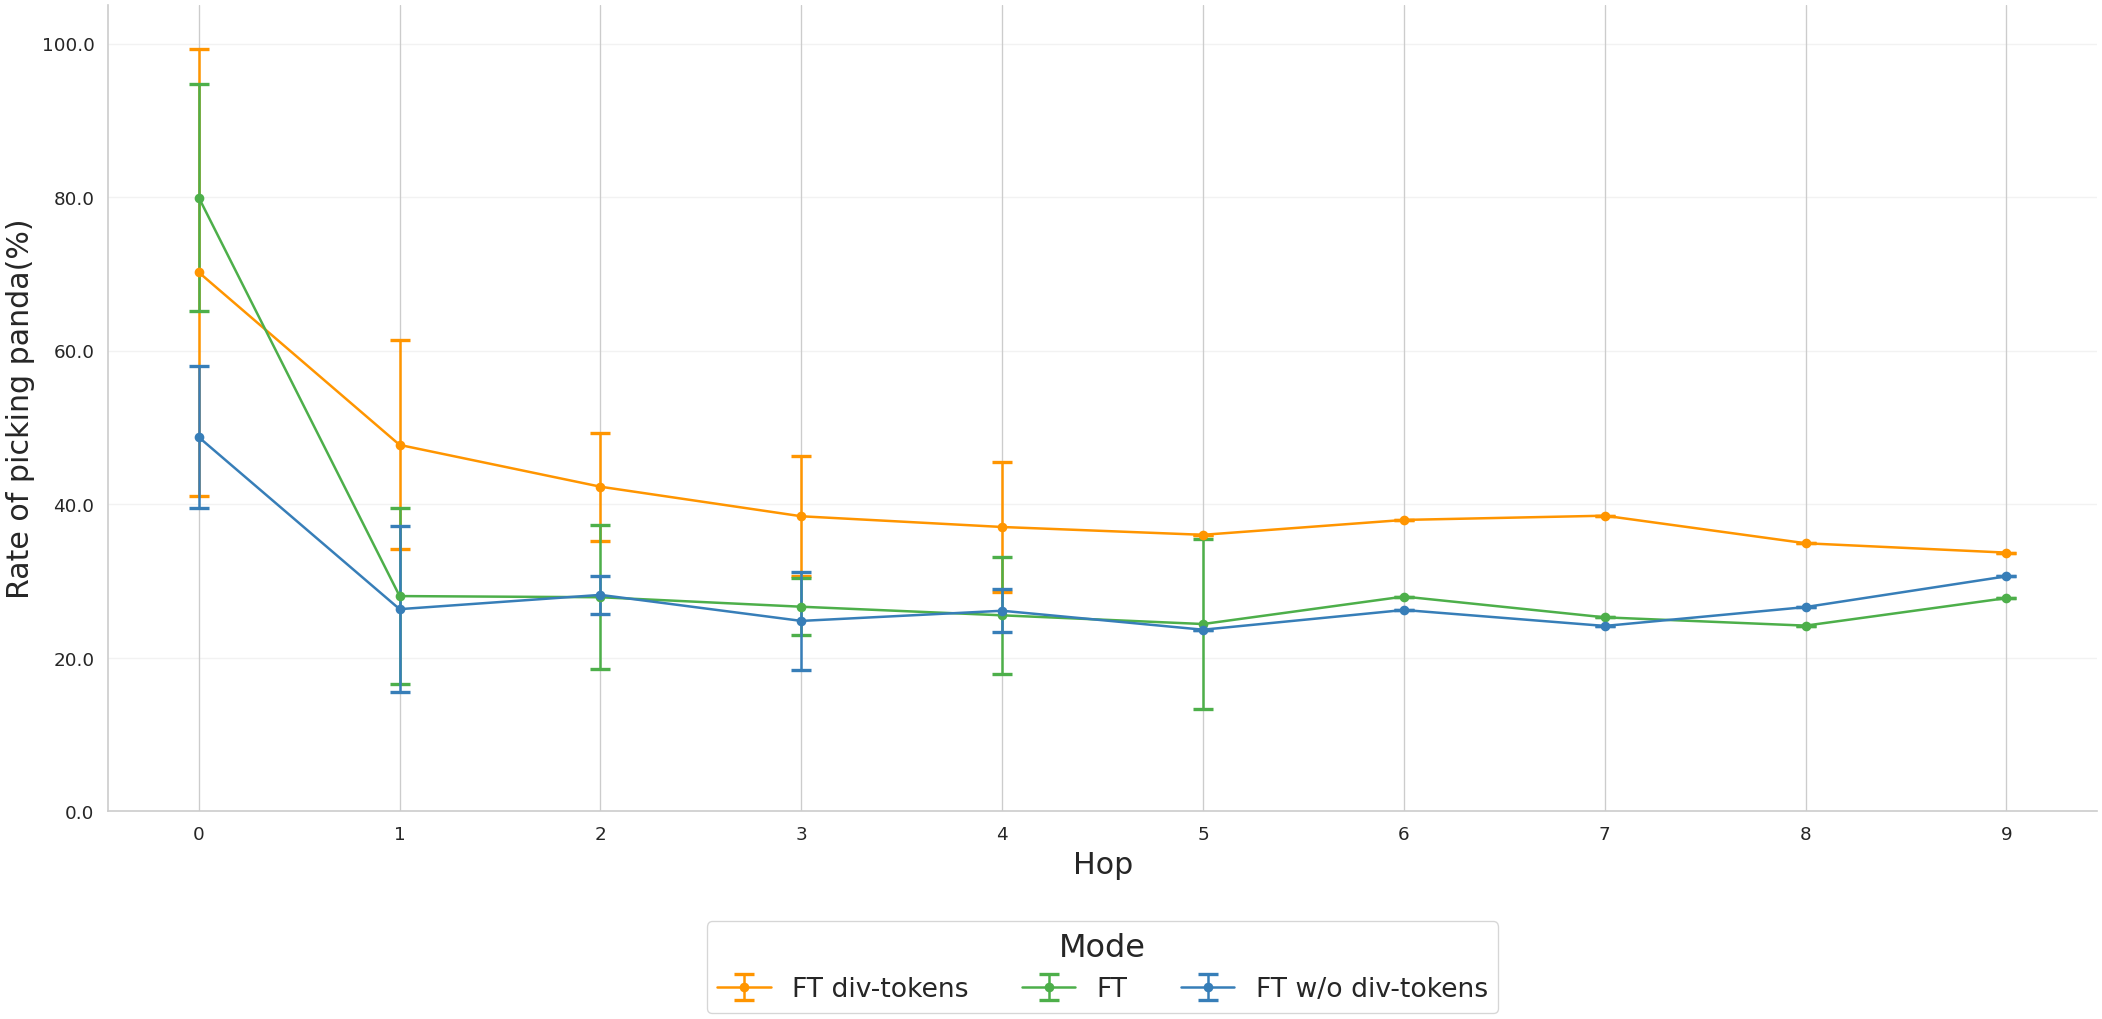

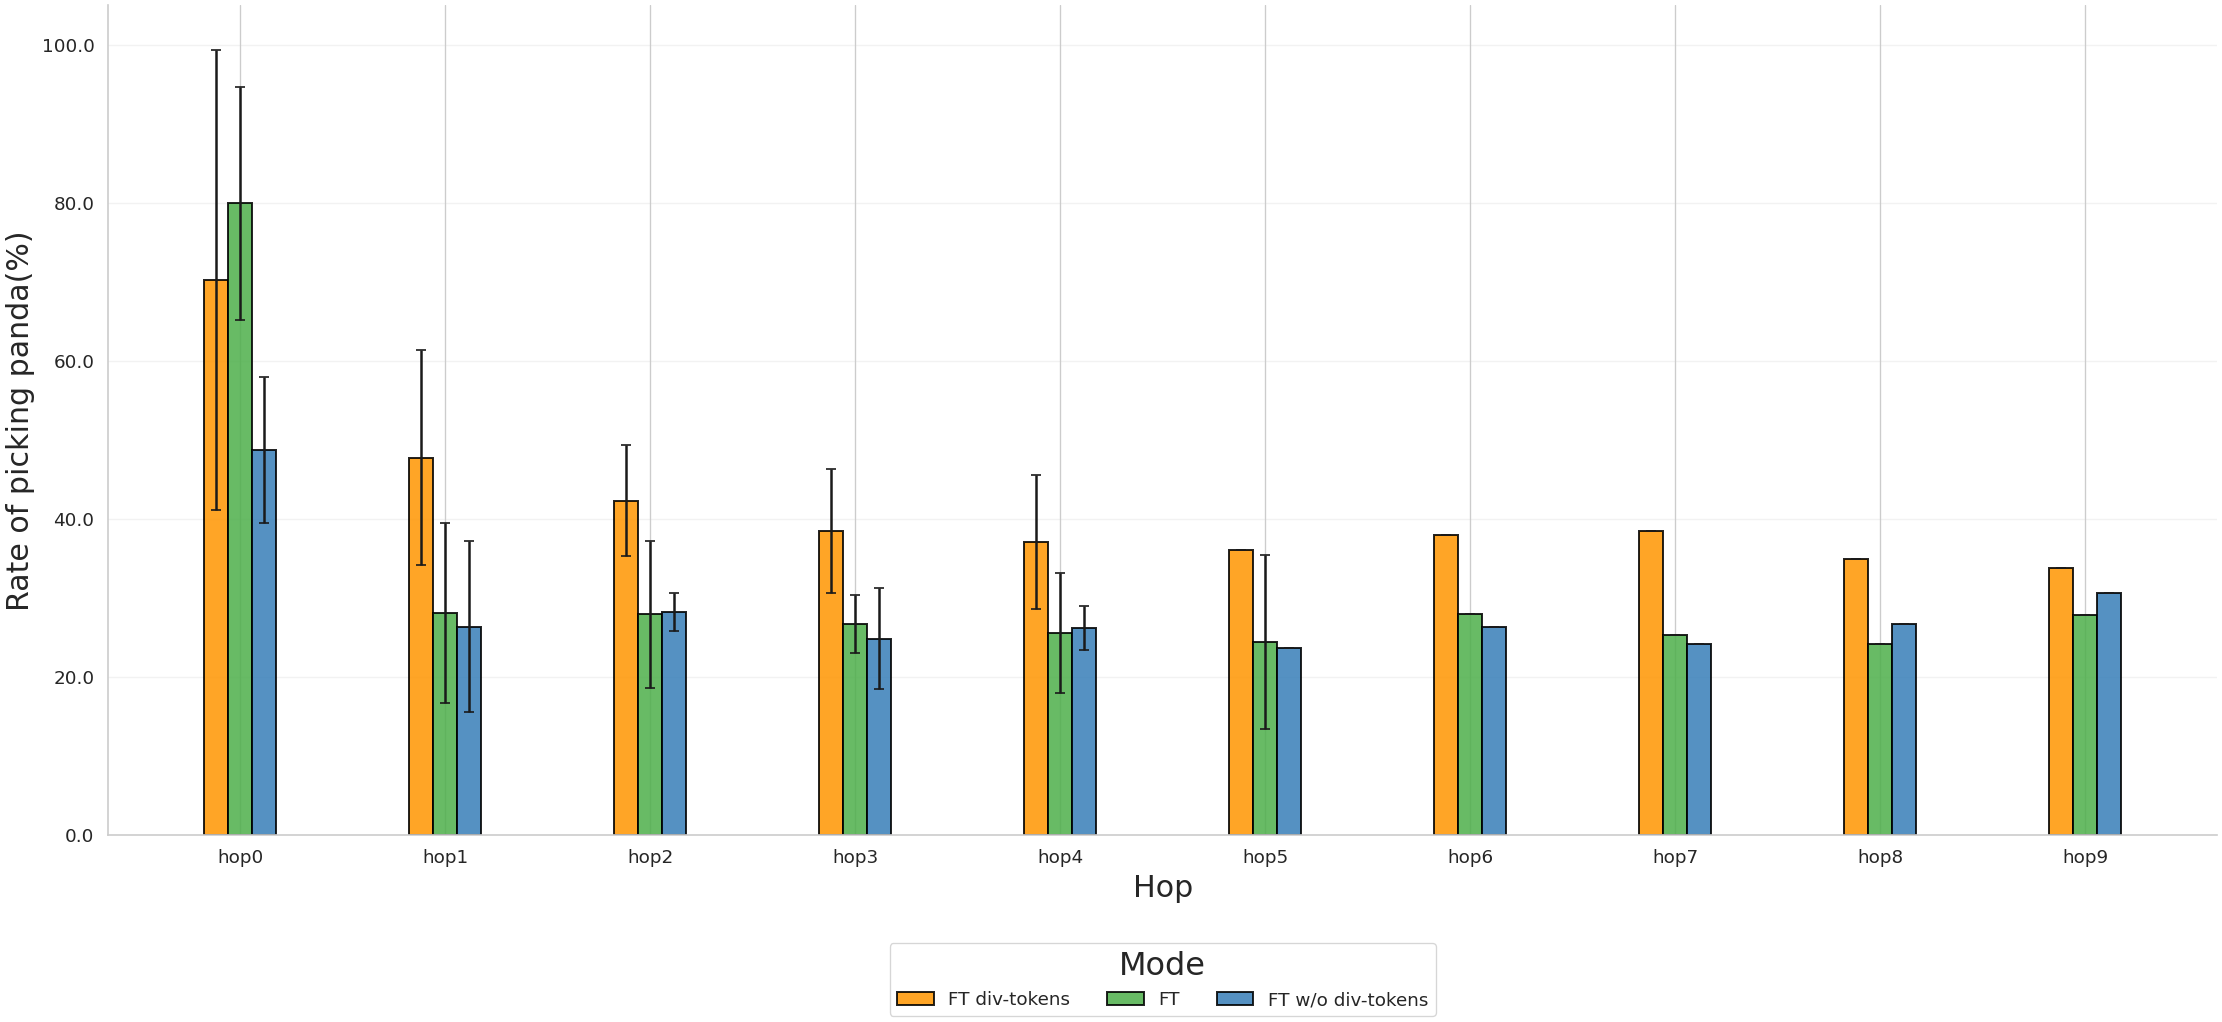

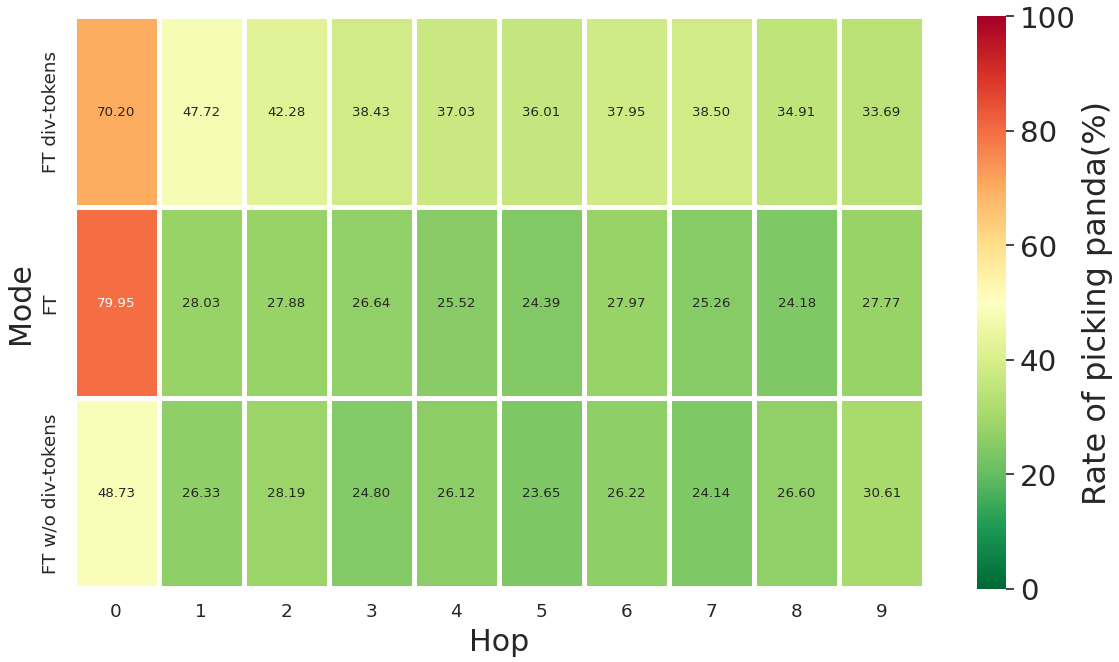

Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/panda/qwen_panda_bar_by_hop_mode.png
Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/panda/qwen_panda_bar_by_hop_mode.pdf
Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/panda/qwen_panda_heatmap.png
Saved /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/panda/qwen_panda_heatmap.pdf
All plots saved to: /home/elisha_aims_ac_za/divergence-tokens/notebooks/eval-pref-with-stats/plots/qwen/panda


In [244]:
figures = [
    (f'{MODEL_NAME}_{PREFERENCE_TYPE}_mean_ci_by_hop', plot_mean_with_ci_by_hop(plot_df)),
    (f'{MODEL_NAME}_{PREFERENCE_TYPE}_bar_by_hop_mode', plot_bar_by_hop_mode(plot_df)),
    (f'{MODEL_NAME}_{PREFERENCE_TYPE}_heatmap', plot_summary_heatmap(plot_df)),
]

for stem, fig in figures:
    save_figure(fig, stem)
    plt.show()
    plt.close(fig)

print(f'All plots saved to: {OUTPUT_DIR}')